In [20]:
import cosmosis
import sys, os
csdir = '/projects/bdne/spandey3/cosmosis-standard-library/'
os.chdir(csdir)
from cosmosis.runtime.config import Inifile
from cosmosis.runtime.pipeline import LikelihoodPipeline
from scipy.stats import norm
from scipy.linalg import sqrtm
from threadpoolctl import threadpool_limits
old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')
pipeline = cosmosis.runtime.pipeline.LikelihoodPipeline(cosmosis.runtime.config.Inifile(f"{csdir}/examples/des-y3-shear_codecompare.ini",
                            override={
                                # ('DEFAULT', '2pt_file'):f"{csdir}/examples/bz_forecast/dv_final/y3nz_lssty10_simulation_wNLA_wmag_wkappaCMB_magfix.fits",
                                ('pipeline', 'values'):'examples/des-y3-shear-values_TATT.ini',
                                    # ('save_2pt','filename'):'output/sim_fid_lsstY10_y3nz_with_bz_mz_balv' + str(alv) + '_malv' + str(mlv) + '_wIA_wmag_magfix.fits',
                                # ('save_2pt','copy_covariance'):f"{csdir}/examples/bz_forecast/dv_final/y3nz_lssty10_simulation_wNLA_wmag_wkappaCMB_magfix.fits",        
                            }))

start_y3fid = pipeline.start_vector()
results_fid_cs_tatt = pipeline.run_results(start_y3fid)





/projects/bdne/spandey3/cosmosis-standard-library/boltzmann/camb/camb_interface.py:183: UserWarning: Option kmin does not have an effect.
  warnings.warn("Option kmin does not have an effect.")
/projects/bdne/spandey3/cosmosis-standard-library/structure/projection/projection_tools/kernel.py:35: UserWarning: Some of your n(z) or other kernels are negative.
  warnings.warn("Some of your n(z) or other kernels are negative.")
/projects/bdne/spandey3/cosmosis-standard-library/shear/cl_to_xi_fullsky/cl_to_xi.py:36: RuntimeWarning: divide by zero encountered in log
  spec = np.exp(self.interp_func(np.log(angle)))


In [3]:
import cosmosis
import sys, os
csdir = '/projects/bdne/spandey3/cosmosis-standard-library/'
os.chdir(csdir)
from cosmosis.runtime.config import Inifile
from cosmosis.runtime.pipeline import LikelihoodPipeline
from scipy.stats import norm
from scipy.linalg import sqrtm
from threadpoolctl import threadpool_limits
old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')
pipeline = cosmosis.runtime.pipeline.LikelihoodPipeline(cosmosis.runtime.config.Inifile(f"{csdir}/examples/des-y3-shear_codecompare.ini",
                            override={
                                # ('DEFAULT', '2pt_file'):f"{csdir}/examples/bz_forecast/dv_final/y3nz_lssty10_simulation_wNLA_wmag_wkappaCMB_magfix.fits",
                                ('pipeline', 'values'):'examples/des-y3-shear-values_NLA.ini',
                                    # ('save_2pt','filename'):'output/sim_fid_lsstY10_y3nz_with_bz_mz_balv' + str(alv) + '_malv' + str(mlv) + '_wIA_wmag_magfix.fits',
                                # ('save_2pt','copy_covariance'):f"{csdir}/examples/bz_forecast/dv_final/y3nz_lssty10_simulation_wNLA_wmag_wkappaCMB_magfix.fits",        
                            }))

start_y3fid = pipeline.start_vector()
results_fid_cs_nla = pipeline.run_results(start_y3fid)






Setting up module consistency
------------------------------

Setting up module bbn_consistency
----------------------------------

Setting up module camb
-----------------------

Setting up module fast_pt
--------------------------

Setting up module fits_nz
--------------------------

Setting up module source_photoz_bias
-------------------------------------

Setting up module IA
---------------------

Setting up module pk_to_cl
---------------------------

Setting up module 2pt_shear
----------------------------

Setting up module shear_m_bias
-------------------------------

Setting up module 2pt_like
---------------------------
Setup all pipeline modules

Om_b h^2             =  0.022853
Om_c h^2             =  0.119977
Om_nu h^2            =  0.000000
Om_darkenergy        =  0.699912
Om_K                 =  0.000000
Om_m (inc Om_u)      =  0.300000
100 theta (CosmoMC)  =  1.043056
Age of universe/GYr  =  13.656
zstar                =  1089.43
r_s(zstar)/Mpc       =  144.07
100*t

/projects/bdne/spandey3/cosmosis-standard-library/boltzmann/camb/camb_interface.py:183: UserWarning: Option kmin does not have an effect.
  warnings.warn("Option kmin does not have an effect.")
/projects/bdne/spandey3/cosmosis-standard-library/structure/projection/projection_tools/kernel.py:35: UserWarning: Some of your n(z) or other kernels are negative.
  warnings.warn("Some of your n(z) or other kernels are negative.")
/projects/bdne/spandey3/cosmosis-standard-library/shear/cl_to_xi_fullsky/cl_to_xi.py:36: RuntimeWarning: divide by zero encountered in log
  spec = np.exp(self.interp_func(np.log(angle)))


In [11]:
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')
%matplotlib inline

probe = 'all'
# deproj = 'cib_1p7'
true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy'  
abs_path_data = '/projects/bdne/spandey3/GODMAX/data'

save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV/')
# df_measure = pk.load(open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/DESxACT_gty_xip_xim_DV_ilc_SZ_yy.pk', 'rb'))
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{true_y_file}.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

gty_dv = data_vec[:80]
sig_gty_dv = np.sqrt(np.diag(cov_total))[:80]

xip_dv = data_vec[80:280]
sig_xip_dv = np.sqrt(np.diag(cov_total))[80:280]


from astropy.io import fits
df_cs = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))

bin1_xip_dv = df_cs['xip'].data['BIN1']
bin2_xip_dv = df_cs['xip'].data['BIN2']

xim_dv = data_vec[280:]
sig_xim_dv = np.sqrt(np.diag(cov_total))[280:]
bin1_xim_dv = df_cs['xim'].data['BIN1']
bin2_xim_dv = df_cs['xim'].data['BIN2']

theta_val = df_cs['xip'].data['ANG'][0:20]



In [16]:
results_fid_cs_tatt.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')]/results_fid_cs_nla.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')]


array([1.00255651, 1.00246764, 1.00233835, 1.00216367, 1.00194547,
       1.00169369, 1.00142485, 1.00115791, 1.00090971, 1.0006919 ,
       1.00051016, 1.00036505, 1.00025363, 1.00017106, 1.00011191,
       1.0000709 , 1.0000428 , 1.0000221 , 1.0000113 , 1.00000202])

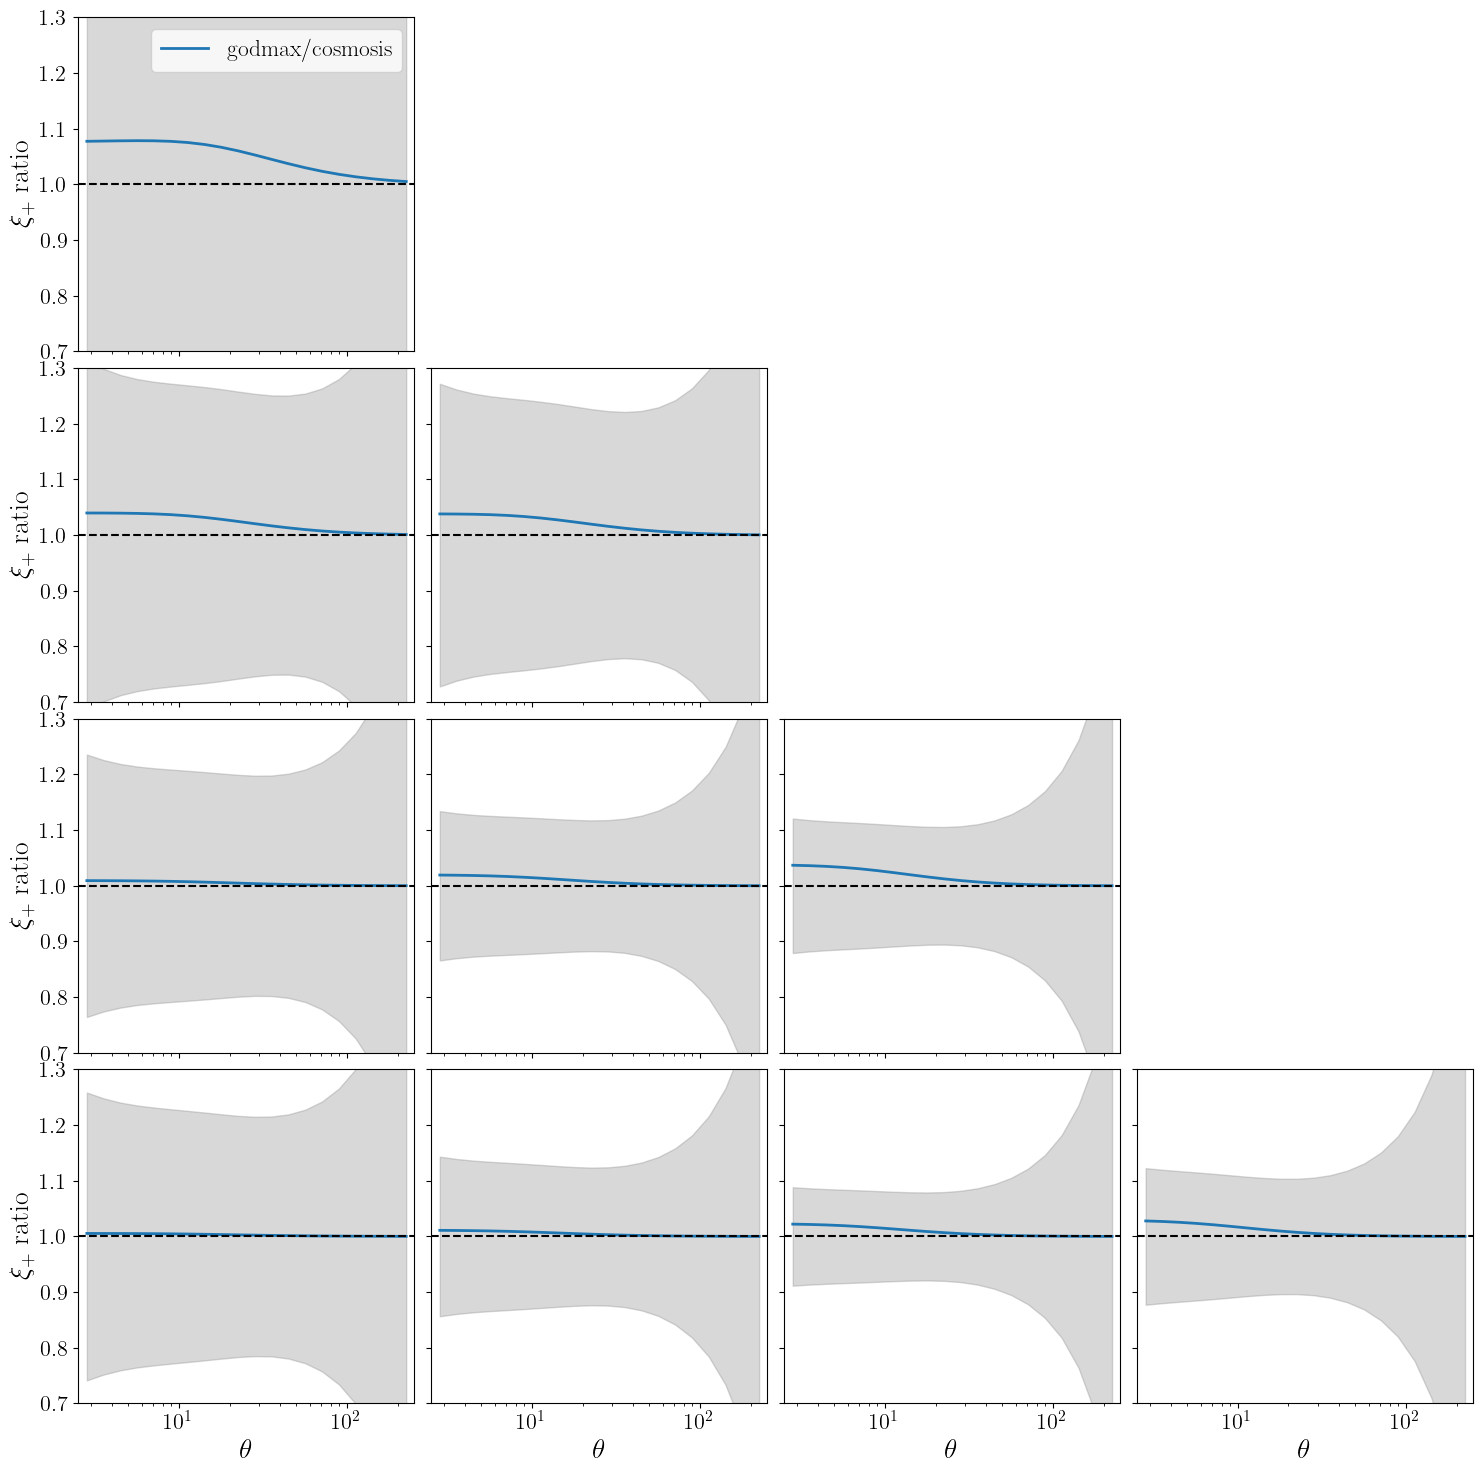

In [21]:
rad2arcmin = 180.0 * 60.0 / np.pi
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.fill_between(theta_val, 1-sig_xip_dv[indsel]/results_fid_cs_nla.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')],1+sig_xip_dv[indsel]/results_fid_cs_nla.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], alpha=0.3, color='gray')
            ax.plot(theta_val, results_fid_cs_tatt.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')]/results_fid_cs_nla.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='godmax/cosmosis', lw=2)

            # ax.plot(rad2arcmin*results_fid_cs.block[('shear_xi_plus', 'theta')], , label='cosmosis', lw=2)
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            # ax.set_ylim(0, 9e-5)
            ax.set_ylim(0.7,1.3)     
            ax.axhline(1, color='k', ls='--')       
            ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{+}$ ratio', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
pl.show()




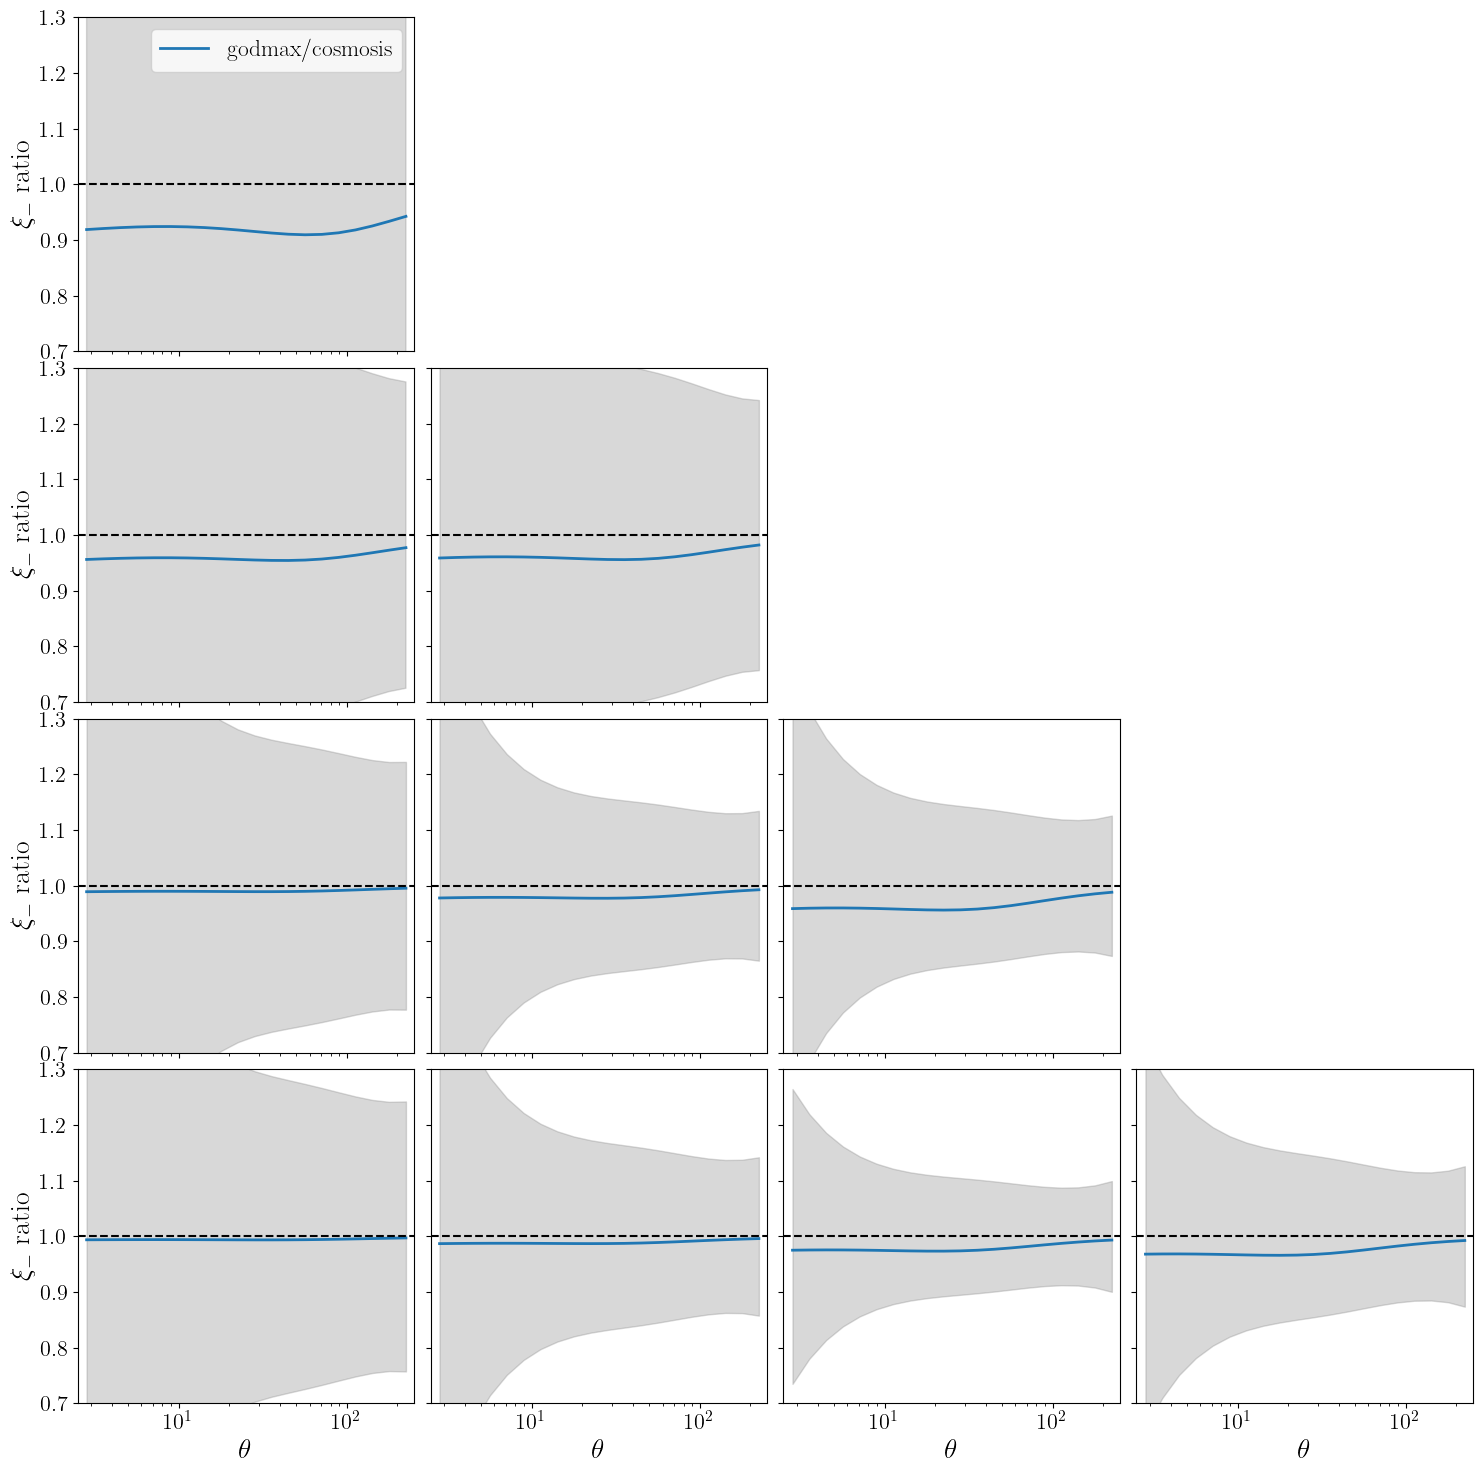

In [22]:
rad2arcmin = 180.0 * 60.0 / np.pi
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.fill_between(theta_val, 1-sig_xim_dv[indsel]/results_fid_cs_nla.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')],1+sig_xim_dv[indsel]/results_fid_cs_nla.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')], alpha=0.3, color='gray')
            ax.plot(theta_val, results_fid_cs_tatt.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')]/results_fid_cs_nla.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')], label='godmax/cosmosis', lw=2)

            # ax.plot(rad2arcmin*results_fid_cs.block[('shear_xi_plus', 'theta')], , label='cosmosis', lw=2)
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            # ax.set_ylim(0, 9e-5)
            ax.set_ylim(0.7,1.3)     
            ax.axhline(1, color='k', ls='--')       
            ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{-}$ ratio', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
pl.show()


